Test cases for N-path filter

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import importlib
import utilities
importlib.reload(utilities)

from utilities import rc_lpf, npath_filter, plot_psd, rand_qpsk

Passband Input

Total number of input samples: 327680


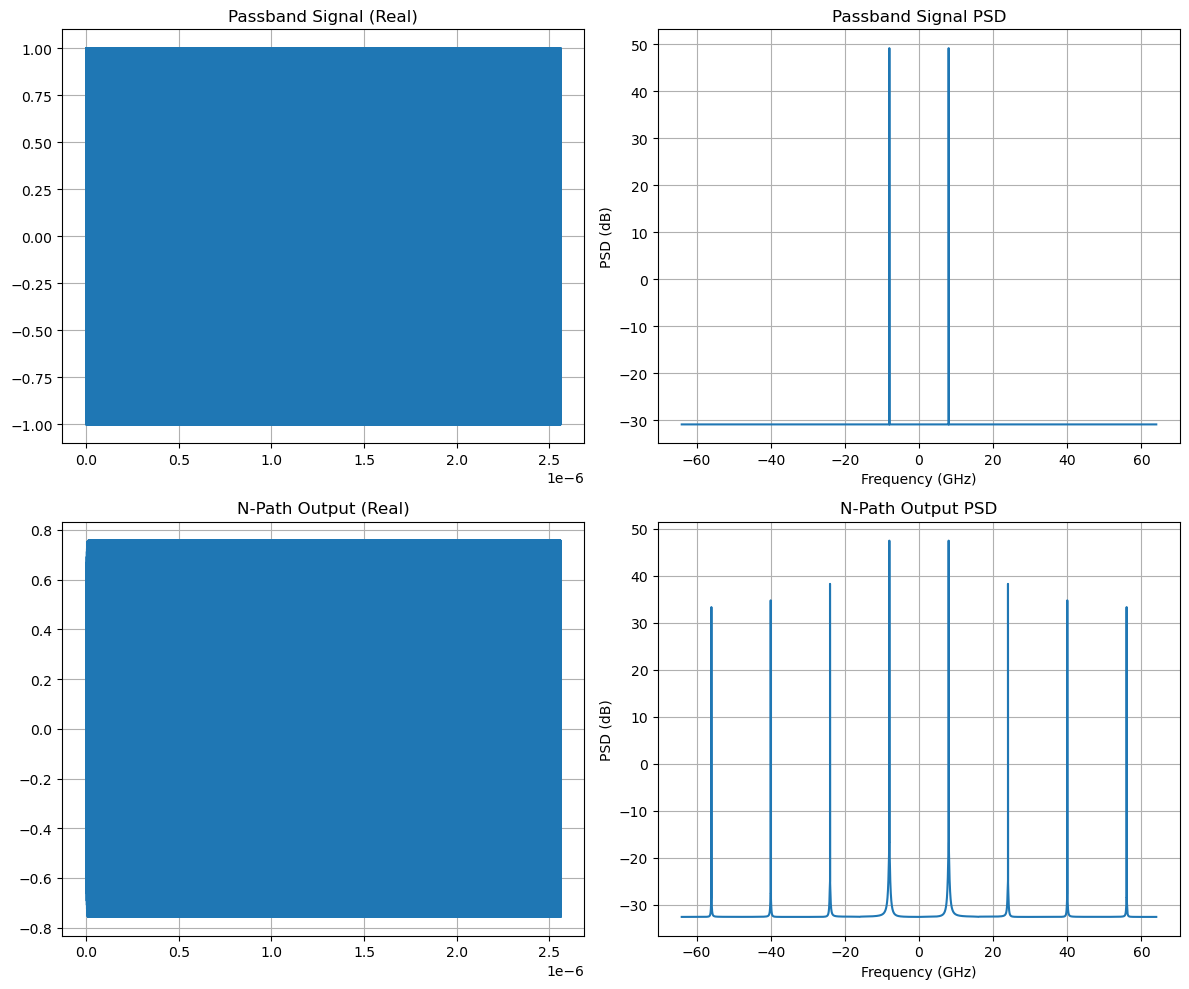

In [2]:
# ==============================
# SYSTEM PARAMETERS
# ==============================

f_p   = 8e9             # Passband carrier frequency
f_lo  = 8e9             # LO frequency for N-path switching
N     = 4               # Number of paths in N-path receiver
f_s   = 4 * N * f_lo    # Simulation sampling rate
bw1   = 400e6           # RC bandwidth of N-path filter
T     = 1024 / bw1      # Signal duration
G     = 2               # Baseband amplifier gain

assert f_s % (N * f_lo) == 0, "Sampling rate must be an integer multiple of N * f_lo"

# ==============================
# SUB PARAMETERS
# ==============================

R1 = 1                            # N-path RC resistance
C1 = 1 / (2 * np.pi * R1 * bw1)   # N-path RC capacitor

t   = np.arange(0, T, 1/f_s)      # Time vector

# ==============================
# PASSBAND SIGNAL
# ==============================

x_p = np.real(np.exp(1j * 2*np.pi*f_p*t))
print(f"Total number of input samples: {len(x_p)}")

# ==============================
# N-PATH Receiver (MIXER + LPF)
# ==============================

y_out = npath_filter(x_p, N, R1, C1, f_s, f_lo, baseband=False)

# ==============================
# PLOTS: TIME DOMAIN + PSD
# ==============================

plt.figure(figsize=(12, 10))

# Passband signal
plt.subplot(2,2,1)
plt.plot(t, np.real(x_p))
plt.title("Passband Signal (Real)")
plt.grid(True)

plt.subplot(2,2,2)
plot_psd(x_p, f_s, "Passband Signal PSD")

# N-path output
plt.subplot(2,2,3)
plt.plot(t, np.real(y_out))
plt.title("N-Path Output (Real)")
plt.grid(True)

plt.subplot(2,2,4)
plot_psd(y_out, f_s, "N-Path Output PSD")

plt.tight_layout()
plt.show()

Stopband Input

Total number of input samples: 3276800


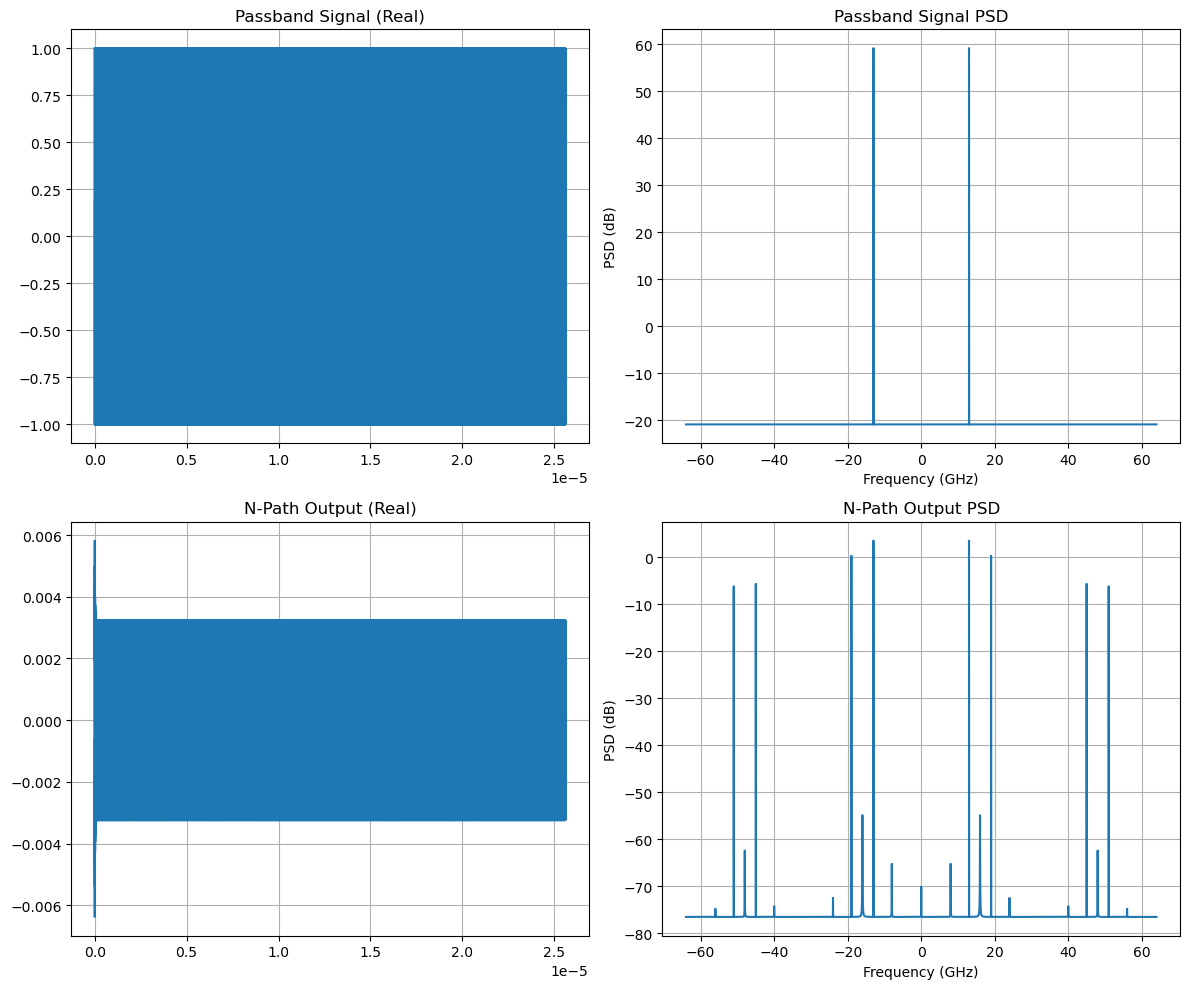

In [3]:
# ==============================
# SYSTEM PARAMETERS
# ==============================

f_p   = 13e9            # Passband carrier frequency
f_lo  = 8e9             # LO frequency for N-path switching
N     = 4               # Number of paths in N-path receiver
f_s   = 4 * N * f_lo    # Simulation sampling rate
bw1   = 40e6            # RC bandwidth of N-path filter
T     = 1024 / bw1      # Signal duration
G     = 2               # Baseband amplifier gain

assert f_s % (N * f_lo) == 0, "Sampling rate must be an integer multiple of N * f_lo"

# ==============================
# SUB PARAMETERS
# ==============================

R1 = 1                            # N-path RC resistance
C1 = 1 / (2 * np.pi * R1 * bw1)   # N-path RC capacitor

t   = np.arange(0, T, 1/f_s)      # Time vector

# ==============================
# PASSBAND SIGNAL
# ==============================

x_p = np.real(np.exp(1j * 2*np.pi*f_p*t))
print(f"Total number of input samples: {len(x_p)}")

# ==============================
# N-PATH Receiver (MIXER + LPF)
# ==============================

y_out = npath_filter(x_p, N, R1, C1, f_s, f_lo, baseband=False)

# ==============================
# PLOTS: TIME DOMAIN + PSD
# ==============================

plt.figure(figsize=(12, 10))

# Passband signal
plt.subplot(2,2,1)
plt.plot(t, np.real(x_p))
plt.title("Passband Signal (Real)")
plt.grid(True)

plt.subplot(2,2,2)
plot_psd(x_p, f_s, "Passband Signal PSD")

# N-path output
plt.subplot(2,2,3)
plt.plot(t, np.real(y_out))
plt.title("N-Path Output (Real)")
plt.grid(True)

plt.subplot(2,2,4)
plot_psd(y_out, f_s, "N-Path Output PSD")

plt.tight_layout()
plt.show()

Mixture (Passband + Stopband)

Total number of input samples: 327680


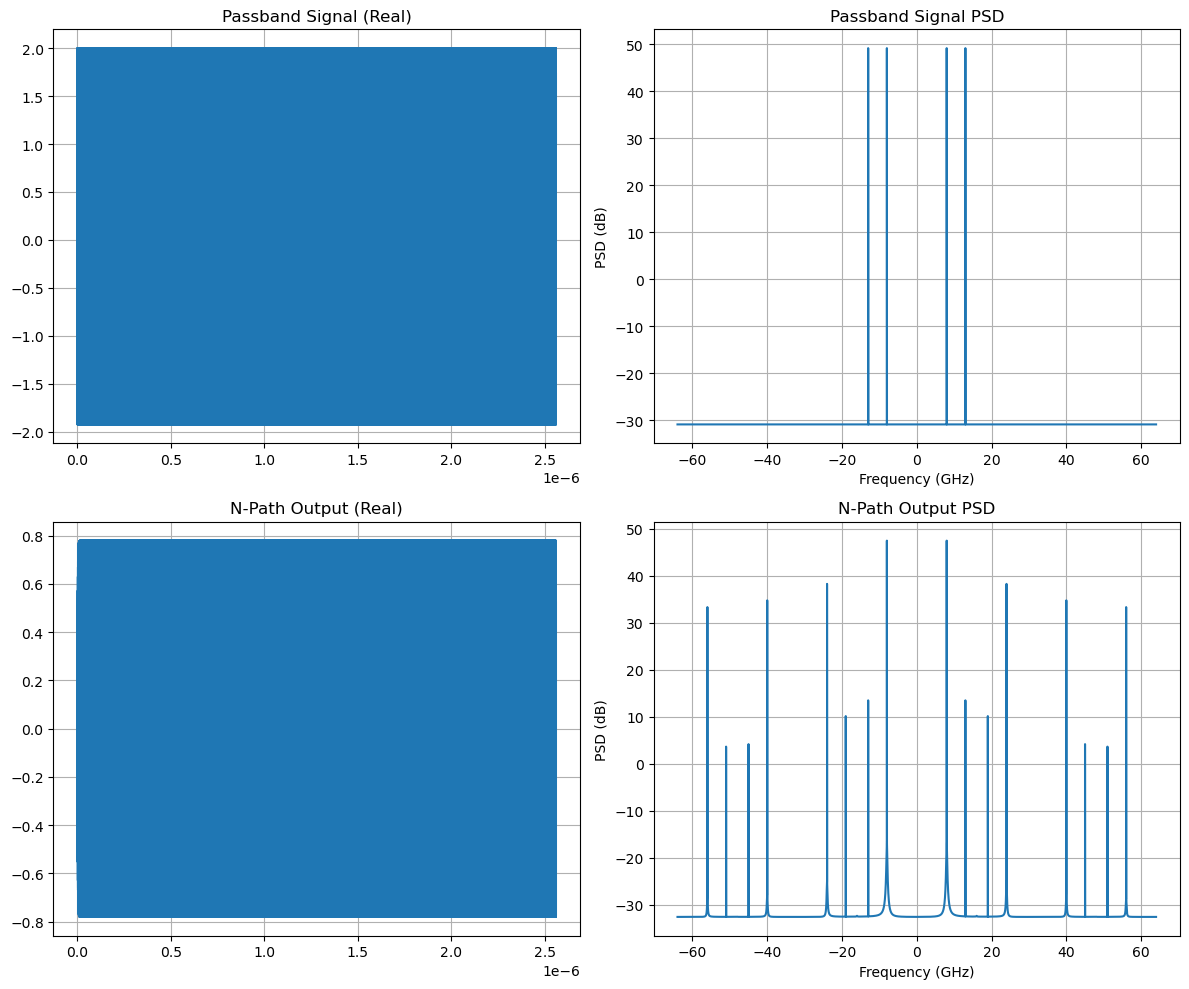

In [4]:
# ==============================
# SYSTEM PARAMETERS
# ==============================

f_p1   = 8e9            # Passband carrier frequency 1
f_p2   = 13e9           # Passband carrier frequency 2
f_lo  = 8e9             # LO frequency for N-path switching
N     = 4               # Number of paths in N-path receiver
f_s   = 4 * N * f_lo    # Simulation sampling rate
bw1   = 400e6           # RC bandwidth of N-path filter
T     = 1024 / bw1      # Signal duration
G     = 2               # Baseband amplifier gain

assert f_s % (N * f_lo) == 0, "Sampling rate must be an integer multiple of N * f_lo"

# ==============================
# SUB PARAMETERS
# ==============================

R1 = 1                            # N-path RC resistance
C1 = 1 / (2 * np.pi * R1 * bw1)   # N-path RC capacitor

t   = np.arange(0, T, 1/f_s)      # Time vector

# ==============================
# PASSBAND SIGNAL
# ==============================

x_p = np.real(np.exp(1j * 2*np.pi*f_p1*t) + np.exp(1j * 2*np.pi*f_p2*t))
print(f"Total number of input samples: {len(x_p)}")

# ==============================
# N-PATH Receiver (MIXER + LPF)
# ==============================

y_out = npath_filter(x_p, N, R1, C1, f_s, f_lo, baseband=False)

# ==============================
# PLOTS: TIME DOMAIN + PSD
# ==============================

plt.figure(figsize=(12, 10))

# Passband signal
plt.subplot(2,2,1)
plt.plot(t, np.real(x_p))
plt.title("Passband Signal (Real)")
plt.grid(True)

plt.subplot(2,2,2)
plot_psd(x_p, f_s, "Passband Signal PSD")

# N-path output
plt.subplot(2,2,3)
plt.plot(t, np.real(y_out))
plt.title("N-Path Output (Real)")
plt.grid(True)

plt.subplot(2,2,4)
plot_psd(y_out, f_s, "N-Path Output PSD")

plt.tight_layout()
plt.show()